Task 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

100%|██████████| 1/1 [00:01<00:00,  1.56s/it]

[0 0] 0 0.012956470277651696
[0 1] 1 0.9838774316391165
[1 0] 1 0.4996289515816573
[1 1] 0 0.5007319319175795


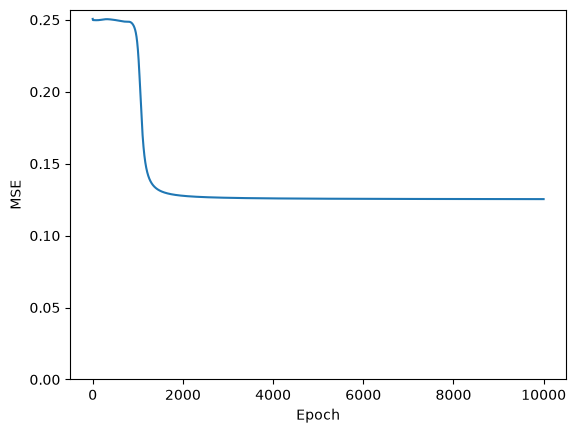

[2.]
(1, 10000)


In [2]:
class NeuralNetworkXOR():
    def __init__(self):
        a = 0.5
        self.weights_0 = np.random.normal(0, a, (3, 2))
        self.weights_1 = np.random.normal(0, a, (3, 1))
        self.x_all = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
        self.y_all = np.array([0, 1, 1, 0])

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def predict(self, input):
        """
        x: (input) neuron including bias
        f = bias + weights * x
        h = sigmoid(f)
        """
        x = np.append(input, 1)

        self.f0 = x @ self.weights_0
        # print(x, self.weights_0)
        self.h0 = self.sigmoid(self.f0)
        self.x1 = np.append(self.h0, 1)

        self.f1 = self.x1 @ self.weights_1
        self.y = self.sigmoid(self.f1)

        return self.y
    
    def mse(self):
        err = np.array([])
        self.num_mistakes = 0
        for X, Y in zip(self.x_all, self.y_all):
            err = np.append(err, (Y - (self.predict(X)))**2)
            if abs(Y - self.predict(X)[0]) > 0.5:
                self.num_mistakes += 1

        mse = np.mean(err)
        return [mse, self.num_mistakes]


    def gradients(self):

        self.gradient_b0 = 0
        self.gradient_w0 = 0
        self.gradient_b1 = 0
        self.gradient_w1 = 0

        for X, Y in zip(self.x_all, self.y_all):
            self.predict(X)

            self.gradient_f1 = (self.y - Y) * (1 - self.y) * self.y
            
            self.gradient_b1 += self.gradient_f1
            self.gradient_w1 += self.gradient_f1 * self.h0 

            self.gradient_f0 = np.diag(self.h0*(1 - self.h0)) @ self.weights_1[:2] * self.gradient_f1
            self.gradient_b0 += self.gradient_f0
            self.gradient_w0 += self.gradient_f0 @ X.reshape((1,2))

        self.gradients0 = np.append(self.gradient_w0, self.gradient_b0.T, axis=0)
        # print(self.gradients0)
        self.gradients1 = np.append(self.gradient_w1, self.gradient_b1.T, axis=0)
        # print(self.gradients1)

    def train(self, num_epoch, learning_rate):

        self.mse_array = np.empty(num_epoch)

        for i in range(num_epoch):
            self.gradients()
            delta_weights_0 = learning_rate * self.gradients0
            self.weights_0 -= delta_weights_0

            delta_weights_1 = learning_rate * np.array([self.gradients1]).T
            # print(delta_weights_1, self.weights_1)
            self.weights_1 -= delta_weights_1

            self.mse_array[i] = self.mse()[0]



num_it = 1
mse_array = np.empty(num_it)
mistakes_array = np.empty(num_it)

for i in tqdm(range(num_it)):
    test = NeuralNetworkXOR()

    test.train(num_epoch=10000, learning_rate=0.75)

    for X, Y in zip(test.x_all, test.y_all):
        prediction = test.predict(X)
        print(X, Y, prediction[0])

    mse_megarray = np.array([test.mse_array]) if i == 0 else np.append(mse_megarray, np.array([test.mse_array]), axis=0)
    mse_array[i] = test.mse_array[-1]
    mistakes_array[i] = test.num_mistakes


plt.plot(test.mse_array)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.ylim(0)
plt.show()

print(mistakes_array)
print(mse_megarray.shape)

In [24]:
# np.save('mse_megarray.npy', mse_megarray)
# np.save('mistakes_array.npy', mistakes_array)

mse_megarray = np.load('mse_megarray.npy', )
mistakes_array = np.load('mistakes_array.npy')
print(mistakes_array)

[1. 2. 0. 0. 0. 2. 2. 2. 0. 0. 2. 2. 0. 1. 0. 0. 0. 1. 0. 1. 0. 2. 2. 2.
 0. 1. 2. 0. 2. 0. 1. 0. 2. 2. 2. 2. 0. 2. 1. 2. 2. 0. 0. 2. 0. 2. 1. 0.
 2. 2. 0. 1. 1. 2. 0. 1. 2. 0. 0. 0. 1. 1. 0. 1. 1. 2. 0. 2. 0. 2. 1. 0.
 0. 0. 0. 0. 1. 1. 1. 2. 1. 2. 0. 2. 0. 1. 0. 1. 1. 0. 2. 2. 0. 0. 1. 2.
 0. 1. 0. 2.]


[0.28305352 0.26951258 0.26071654 ... 0.12525323 0.1252532  0.12525318]
[0.25526951 0.2524979  0.25115528 ... 0.00041904 0.00041898 0.00041891]
[0.26709167 0.25873168 0.25426739 ... 0.16831547 0.16831475 0.16831404]


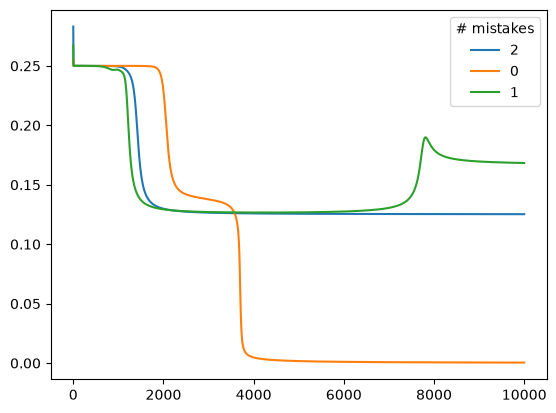

In [27]:
p=11
for i, arr in enumerate(mse_megarray[p:p+3]):
    print(arr)
    plt.plot(arr, label=int(mistakes_array[i+p]))

plt.legend(title='# mistakes')
plt.show()
